[info] Using CUDA (devices=1)
[info] Loading data from /scratch/pp3051/weather


/ext3/miniforge3/lib/python3.12/site-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  _C._set_float32_matmul_precision(precision)


[info] Found supervised pair files (X_*, y_*)
[pairs] supervised | train=163838, val=20478, test=20478
[norm] u: mean=1.29e-12 std=1.309 range=[-5.279, 5.331]
[norm] du: mean=3.623e-13 std=0.2332 range=[-4.949, 5.271]
[train] examples: 655352 | Cin=11, S=2
[dataloader] using 8 workers, pin_memory=True
[optimize] Model compiled with torch.compile


W1204 22:30:36.824000 3296691 site-packages/torch/fx/experimental/symbolic_shapes.py:6833] [0/1] _maybe_guard_rel() was called on non-relation expression Eq(s74, s99) | Eq(s99, 1)
W1204 22:31:01.679000 3296691 site-packages/torch/fx/experimental/symbolic_shapes.py:6833] [0/2] _maybe_guard_rel() was called on non-relation expression Eq(s74, s99) | Eq(s99, 1)


epoch 001 | train loss 6.773521e-03 rmse 4.487708e-02 | val loss 5.303493e-03 rmse 3.547402e-02
epoch 002 | train loss 4.536938e-03 rmse 3.564309e-02 | val loss 4.946223e-03 rmse 3.478086e-02
epoch 003 | train loss 4.065619e-03 rmse 3.344141e-02 | val loss 4.631694e-03 rmse 3.333319e-02
epoch 004 | train loss 3.842948e-03 rmse 3.238110e-02 | val loss 4.174733e-03 rmse 3.145396e-02
epoch 005 | train loss 3.696164e-03 rmse 3.158729e-02 | val loss 4.640882e-03 rmse 3.509678e-02
epoch 006 | train loss 3.570762e-03 rmse 3.106915e-02 | val loss 4.327538e-03 rmse 3.304396e-02
epoch 007 | train loss 3.473128e-03 rmse 3.053941e-02 | val loss 4.007220e-03 rmse 3.113495e-02
epoch 008 | train loss 3.400621e-03 rmse 3.015061e-02 | val loss 4.417956e-03 rmse 3.430019e-02
epoch 009 | train loss 3.335929e-03 rmse 2.977576e-02 | val loss 4.991492e-03 rmse 3.853847e-02
epoch 010 | train loss 3.281494e-03 rmse 2.942633e-02 | val loss 5.011285e-03 rmse 3.832952e-02
lr reduced: 0.002 -> 0.001 (plateau)
epo

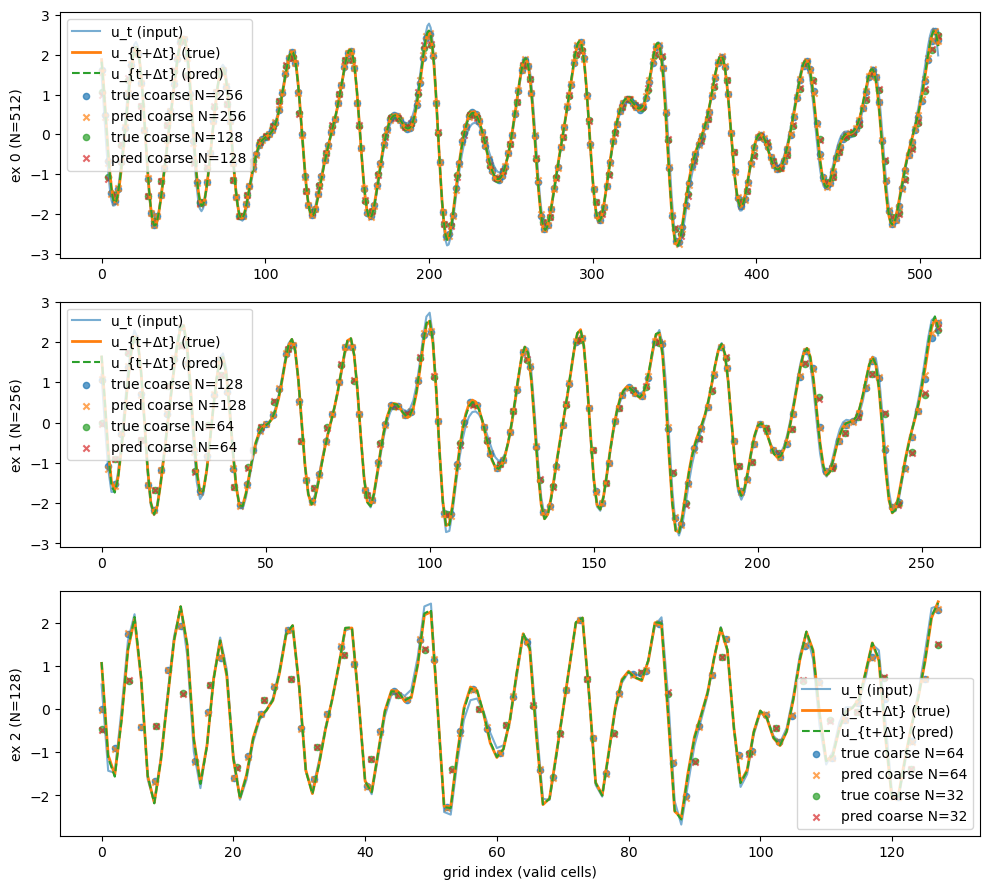


[rollout] using ks_data.npy for long rollout
[rollout] ks_data as (n_traj=1, T=81, N=512)
[rollout] starting from traj 0, index T0=5, t≈3.125
[rollout] steps: 75
preds shape: (76, 512) | truth shape: (76, 512)


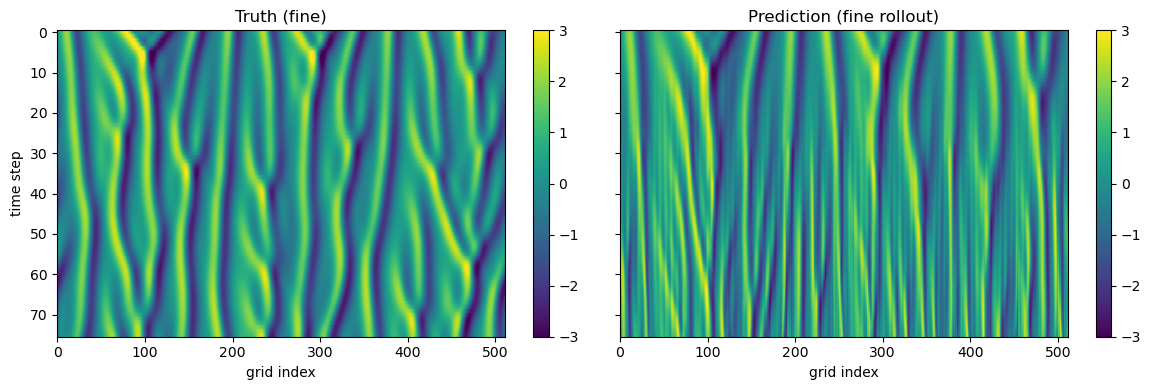

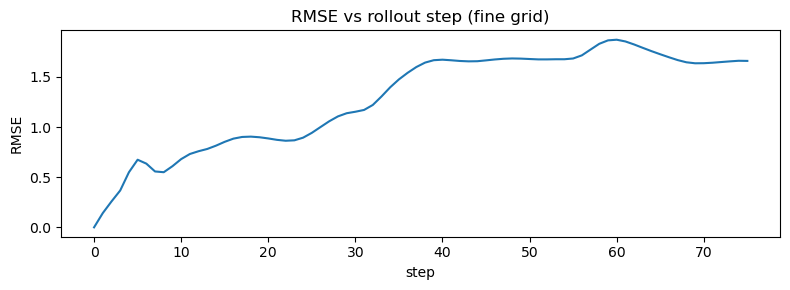

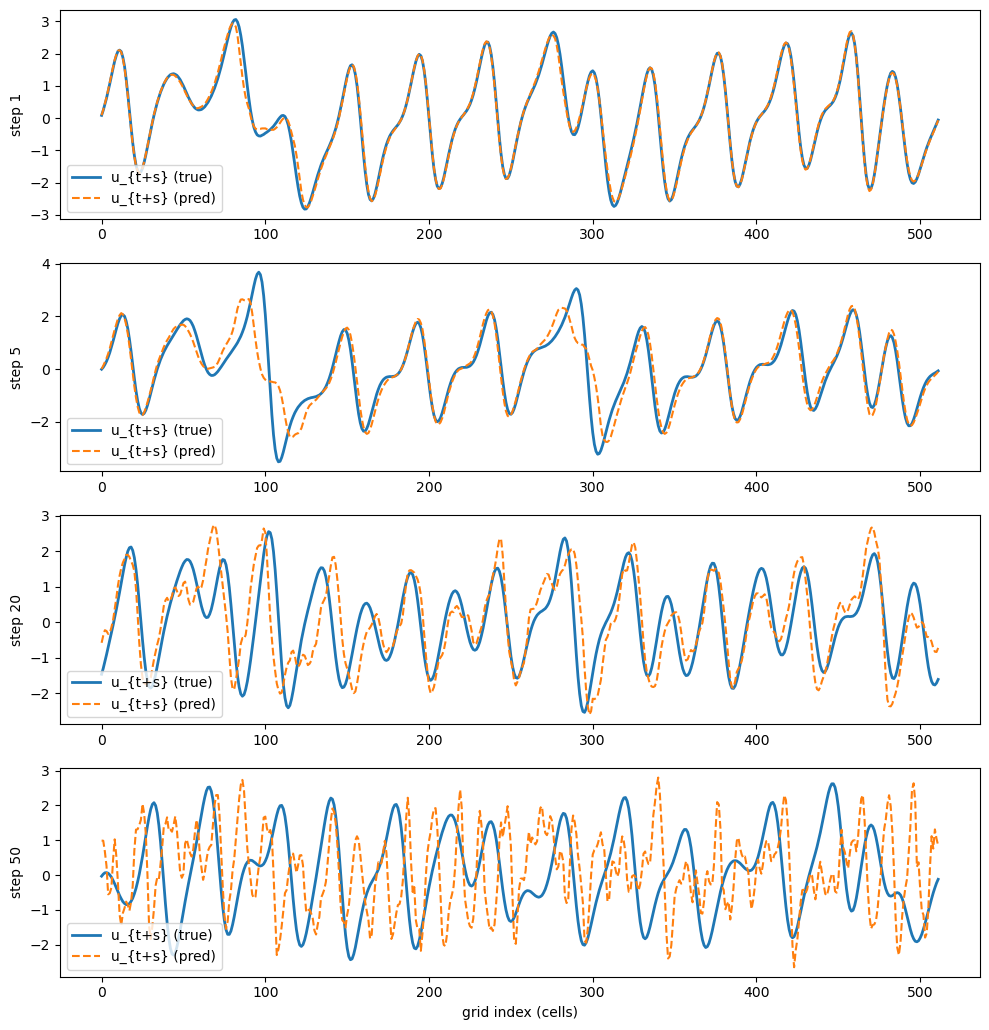

[rollout] visualising coarse grid with N=256


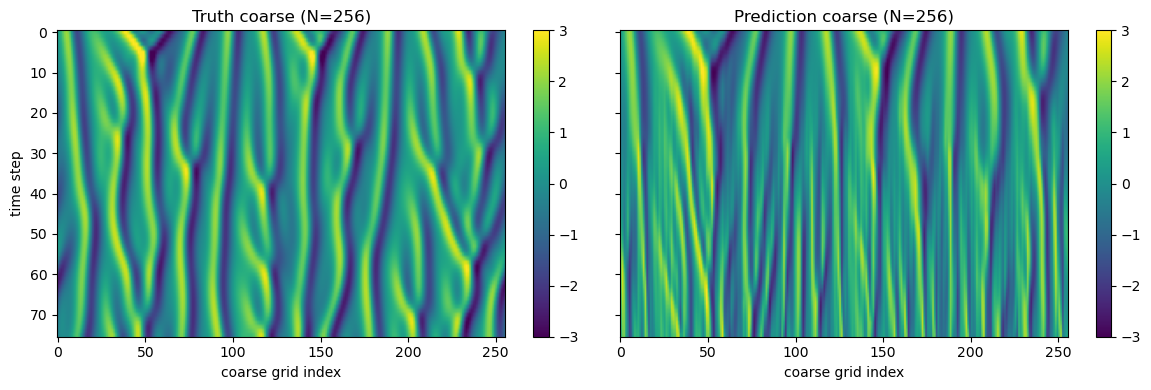

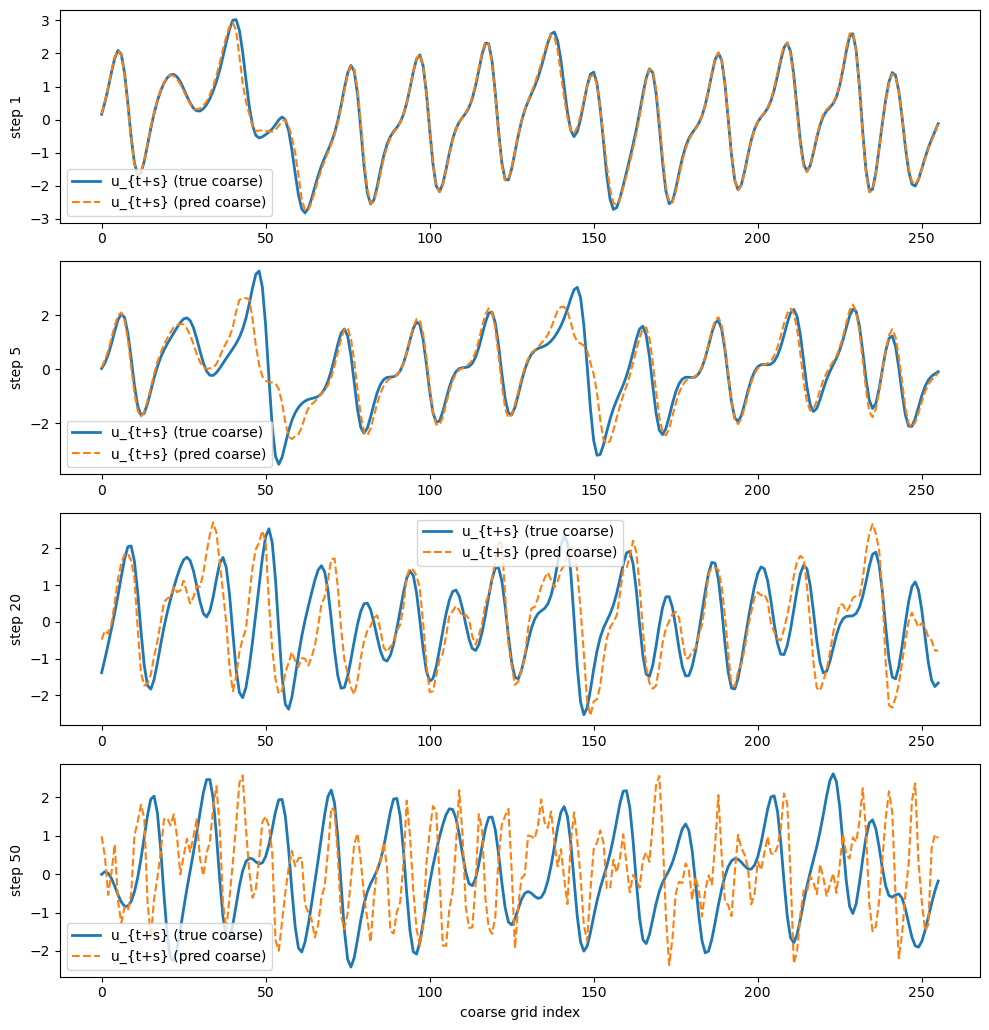

[rollout] visualising coarse grid with N=128


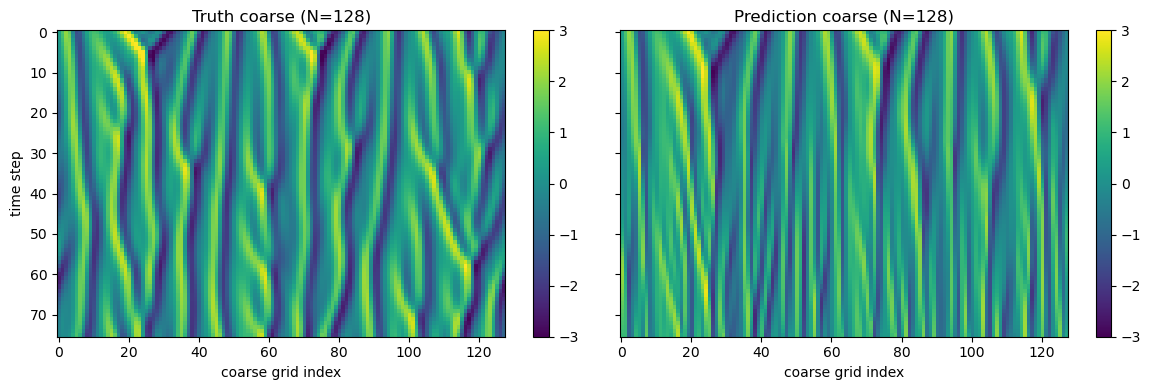

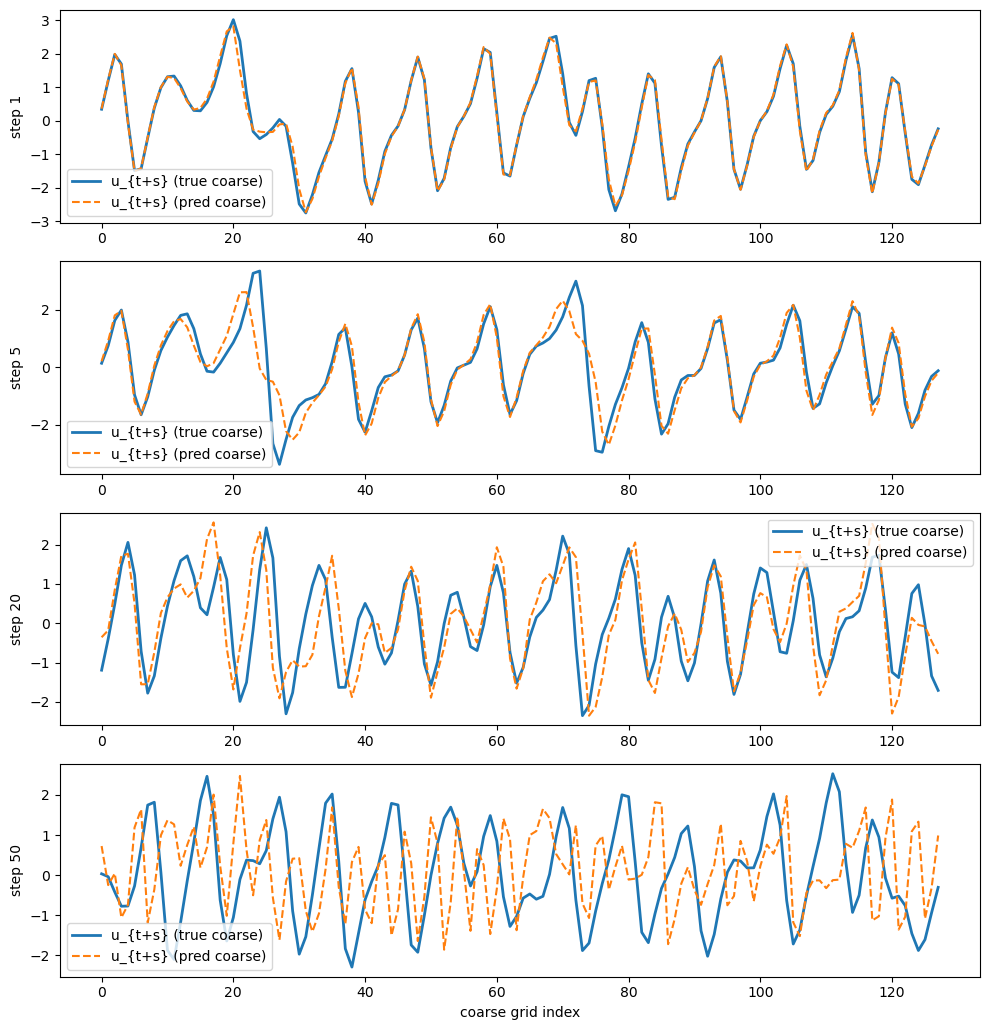

Done.


In [1]:
#!/usr/bin/env python
# coding: utf-8

"""
grid_agnostic_u_timeseries_with_bn_dropout.py

Time-series prediction of wind u(x, t+Δt) from u(x, t), resolution-agnostic.

- Multi-resolution KS data (native + regular downsample + irregular masks)
- 3-frame input (u_{t-2}, u_{t-1}, u_t) + Fourier positional encodings
- Fully-convolutional 1D model with scalar conditioning
- Batch/LayerNorm, dropout, weight decay
- One-step metrics + K-step rollouts
- Visualisation for both native and coarse grids
"""

# -------------------------------
# Imports and minimal config
# -------------------------------
import os, math, random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 1337
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DATA_DIR = Path(".")                       # folder with KS .npy files
SAVE_DIR = Path("./runs_grid_agnostic")    # where best.pt will be written
SAVE_DIR.mkdir(parents=True, exist_ok=True)

if DEVICE == "cuda":
    print(f"[info] Using CUDA (devices={torch.cuda.device_count()})")
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass
    try:
        torch.backends.cuda.enable_flash_sdp(True)
    except Exception:
        pass
else:
    print("[info] Using CPU")

# ============================================
# Hyperparameters
# ============================================
FREQS = (1, 2, 4, 8)          # Fourier PE frequencies
USE_RESIDUAL_TARGET = True    # predict Δu, then add u

BATCH_SIZE = 64 if DEVICE == "cuda" else 32
LR = 2e-3
EPOCHS = 50
VAL_EVERY = 1

# Normalization, regularization
NORM_TYPE = "batch"           # "batch" or "layer"
DROPOUT_P = 0.1               # dropout probability
WEIGHT_DECAY = 1e-4           # AdamW weight decay

# early stopping
ES_PATIENCE = 6
ES_MIN_DELTA = 1e-5
ES_WARMUP = 5

# small rollout loss during training (stability) – currently disabled
ROLLOUT_K = 0  # 3
ROLLOUT_W = 0  # 0.10


# ============================================
# Data loading & utilities
# ============================================
def try_load_arrays(data_dir: Path):
    """
    Two modes:
      1) supervised_pairs: X_train.npy, y_train.npy, X_val.npy, y_val.npy, X_test.npy, y_test.npy
      2) ks_full: ks_data.npy (+ ks_spatial_grid.npy, ks_time.npy)

    For mode 1 we STILL try to load ks_spatial_grid/ks_time to define Lx, dt.
    """
    sup_files = ["X_train.npy", "y_train.npy", "X_val.npy", "y_val.npy", "X_test.npy", "y_test.npy"]
    if all((data_dir / f).exists() for f in sup_files):
        d = {"mode": "supervised_pairs"}
        for f in sup_files:
            d[f[:-4]] = np.load(data_dir / f)

        if (data_dir / "ks_spatial_grid.npy").exists():
            d["x"] = np.load(data_dir / "ks_spatial_grid.npy")
        elif (data_dir / "x.npy").exists():
            d["x"] = np.load(data_dir / "x.npy")

        if (data_dir / "ks_time.npy").exists():
            d["t"] = np.load(data_dir / "ks_time.npy")
        elif (data_dir / "t.npy").exists():
            d["t"] = np.load(data_dir / "t.npy")

        print("[info] Found supervised pair files (X_*, y_*)")
        return d

    if (data_dir / "ks_data.npy").exists():
        d = {"mode": "ks_full", "ks_data": np.load(data_dir / "ks_data.npy")}
        if (data_dir / "ks_spatial_grid.npy").exists():
            d["x"] = np.load(data_dir / "ks_spatial_grid.npy")
        if (data_dir / "ks_time.npy").exists():
            d["t"] = np.load(data_dir / "ks_time.npy")
        print("[info] Found ks_data.npy (full KS field)")
        return d

    raise FileNotFoundError("No recognized KS data files found in DATA_DIR.")


def infer_Lx_dt(d):
    if "x" in d:
        x = d["x"]
        Lx = float((x[1] - x[0]) * len(x))
    else:
        Lx = 2 * math.pi
    if "t" in d and len(d["t"]) >= 2:
        dt = float(d["t"][1] - d["t"][0])
    else:
        dt = None
    return Lx, dt


def build_pairs_from_supervised(d):
    """
    X_*, y_* have shape [n_pairs, N] (one sample per row).
    Returns (tr_pairs, va_pairs, te_pairs, Lx, dt),
    each list element is (u_{t-2} (N,), u_{t-1} (N,), u_t (N,), u_{t+1} (N,)).
    """
    Xtr, Ytr = d["X_train"], d["y_train"]
    Xva, Yva = d["X_val"],   d["y_val"]
    Xte, Yte = d["X_test"],  d["y_test"]

    tr_pairs = [(Xtr[i-2], Xtr[i-1], Xtr[i], Ytr[i]) for i in range(2, len(Xtr))]
    va_pairs = [(Xva[i-2], Xva[i-1], Xva[i], Yva[i]) for i in range(2, len(Xva))]
    te_pairs = [(Xte[i-2], Xte[i-1], Xte[i], Yte[i]) for i in range(2, len(Xte))]

    Lx, dt = infer_Lx_dt(d)
    print(f"[pairs] supervised | train={len(tr_pairs)}, val={len(va_pairs)}, test={len(te_pairs)}")
    return tr_pairs, va_pairs, te_pairs, Lx, dt


def build_pairs_from_ks_full(d):
    """
    Fallback: build pairs directly from ks_data.npy if no X_*, y_*.
    ks_data may have shape (n_real, T, N) OR (T, N, n_real) etc.
    We'll rearrange to [n_traj, T, N] and then create (u_{t-2}, u_{t-1}, u_t, u_{t+1}) tuples.
    """
    ks_data = d["ks_data"]
    x = d.get("x", None)
    t = d.get("t", None)

    if ks_data.ndim != 3:
        raise ValueError("Expected ks_data.npy to have 3 dims (realizations, time, space)")

    T_guess = None if t is None else len(t)
    N_guess = None if x is None else len(x)

    shape = ks_data.shape
    print(f"[info] ks_data shape {shape}")

    if T_guess is not None and N_guess is not None:
        a, b, c = shape
        if b == T_guess and c == N_guess:
            U = ks_data      # [n_traj, T, N]
        elif a == T_guess and b == N_guess:
            U = np.transpose(ks_data, (2, 0, 1))  # [T, N, n_traj] -> [n_traj, T, N]
        elif a == T_guess and c == N_guess:
            U = np.transpose(ks_data, (1, 0, 2))  # [T, n_traj, N] -> [n_traj, T, N]
        else:
            raise ValueError("Cannot match ks_data axes with ks_time/ks_spatial_grid.")
    else:
        U = ks_data  # assume [n_traj, T, N]

    n_traj, T, N = U.shape
    print(f"[info] interpreted ks_data as (n_traj={n_traj}, T={T}, N={N})")

    tr_pairs, va_pairs, te_pairs = [], [], []
    T_pairs = T - 1
    cut1 = int(0.7 * T_pairs)
    cut2 = int(0.85 * T_pairs)
    for k in range(n_traj):
        for ti in range(2, T_pairs):  # need u_{t-2}, u_{t-1}
            triplet = (U[k, ti-2], U[k, ti-1], U[k, ti], U[k, ti+1])
            if ti < cut1:
                tr_pairs.append(triplet)
            elif ti < cut2:
                va_pairs.append(triplet)
            else:
                te_pairs.append(triplet)

    Lx, dt = infer_Lx_dt(d)
    print(f"[pairs] ks_full | train={len(tr_pairs)}, val={len(va_pairs)}, test={len(te_pairs)}")
    return tr_pairs, va_pairs, te_pairs, Lx, dt, U  # U for rollout


def area_average_downsample(u_hi: np.ndarray, Lx: float, Nx_lo: int):
    Nx_hi = u_hi.shape[-1]
    assert Nx_hi % Nx_lo == 0, f"{Nx_hi=} not divisible by {Nx_lo=}"
    r = Nx_hi // Nx_lo
    u_lo = u_hi.reshape(Nx_lo, r).mean(axis=1, dtype=np.float32)
    dx = Lx / Nx_lo
    x_lo = (np.arange(Nx_lo, dtype=np.float32) + 0.5) * dx
    w_lo = np.full(Nx_lo, dx, dtype=np.float32)
    mask_lo = np.ones(Nx_lo, dtype=bool)
    return u_lo, x_lo, w_lo, mask_lo


def irregular_subsample(u: np.ndarray, Lx: float, keep_frac: float, rng: np.random.Generator):
    Nx = u.shape[-1]
    k = max(2, int(np.ceil(keep_frac * Nx)))
    take = np.sort(rng.choice(Nx, size=k, replace=False))
    x = (np.arange(Nx) + 0.5) * (Lx / Nx)
    w = np.full(Nx, Lx / Nx, dtype=np.float32)
    mask = np.zeros(Nx, dtype=bool)
    mask[take] = True
    return u.astype(np.float32), x.astype(np.float32), w, mask


def posenc_from_x(x: np.ndarray, freqs):
    x_min = x.min()
    x_max = x.max()
    x_range = max(1e-12, x_max - x_min)
    x01 = (x - x_min) / x_range

    n_freqs = len(freqs)
    N = x01.shape[-1]
    feats = np.zeros((2 * n_freqs, N), dtype=np.float32)

    for i, f in enumerate(freqs):
        angle = 2 * math.pi * f * x01
        feats[2 * i] = np.sin(angle, dtype=np.float32)
        feats[2 * i + 1] = np.cos(angle, dtype=np.float32)

    return feats  # [Cpe, N]


def make_variants(u_t, u_tp1, Lx, divisors=(2, 4), add_irregular=True, keep_frac=0.35, rng=None):
    if rng is None:
        rng = np.random.default_rng(SEED)
    Nx = u_t.shape[-1]
    variants = []

    # native
    x = (np.arange(Nx) + 0.5) * (Lx / Nx)
    w = np.full(Nx, Lx / Nx, dtype=np.float32)
    m = np.ones(Nx, dtype=bool)
    variants.append(((u_t.astype(np.float32), x.astype(np.float32), w, m),
                     (u_tp1.astype(np.float32), x.astype(np.float32), w, m)))

    # coarse regular
    for d in divisors:
        if Nx % d == 0:
            Nx_lo = Nx // d
            variants.append((area_average_downsample(u_t, Lx, Nx_lo),
                             area_average_downsample(u_tp1, Lx, Nx_lo)))

    # irregular subset
    if add_irregular:
        variants.append((irregular_subsample(u_t, Lx, keep_frac, rng),
                         irregular_subsample(u_tp1, Lx, keep_frac, rng)))

    return variants


class MultiResPairs(Dataset):
    def __init__(self, base_pairs, Lx, dt=None, freqs=FREQS,
                 mix_variants=True, divisors=(2, 4), keep_frac=0.35):
        examples = []
        rng = np.random.default_rng(SEED)

        for u_tm2, u_tm1, u_t, u_tp1 in base_pairs:
            if mix_variants:
                variants = make_variants(
                    u_t, u_tp1, Lx,
                    divisors=divisors,
                    add_irregular=True,
                    keep_frac=keep_frac,
                    rng=rng
                )
            else:
                variants = [((u_t, None, None, None), (u_tp1, None, None, None))]

            for (x_u, x_x, x_w, x_m), (y_u, y_x, y_w, y_m) in variants:
                N = x_u.shape[-1]
                x = x_x if x_x is not None else (np.arange(N) + 0.5) * (Lx / N)
                widths = x_w if x_w is not None else np.full(N, Lx / N, dtype=np.float32)
                mask   = x_m if x_m is not None else np.ones(N, dtype=bool)

                N_orig = u_t.shape[-1]
                if N == N_orig:
                    u_tm2_variant = u_tm2.astype(np.float32)
                    u_tm1_variant = u_tm1.astype(np.float32)
                elif N < N_orig and N_orig % N == 0:
                    u_tm2_variant, _, _, _ = area_average_downsample(u_tm2, Lx, N)
                    u_tm1_variant, _, _, _ = area_average_downsample(u_tm1, Lx, N)
                else:
                    if N < N_orig:
                        u_tm2_variant, _, _, _ = area_average_downsample(u_tm2, Lx, N)
                        u_tm1_variant, _, _, _ = area_average_downsample(u_tm1, Lx, N)
                    else:
                        u_tm2_variant = u_tm2.astype(np.float32)
                        u_tm1_variant = u_tm1.astype(np.float32)

                pe = posenc_from_x(x.astype(np.float32), freqs)   # [Cpe, N]

                examples.append({
                    "u_tm2":  u_tm2_variant,
                    "u_tm1":  u_tm1_variant,
                    "u_t":    x_u.astype(np.float32),
                    "u_tp1":  y_u.astype(np.float32),
                    "x":      x.astype(np.float32),
                    "width":  widths.astype(np.float32),
                    "mask":   mask.astype(bool),
                    "pe":     pe,
                })

        self.examples = examples
        self.Lx = float(Lx)
        self.dt = float(dt) if dt is not None else None
        self.freqs = freqs

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, i):
        e = self.examples[i]
        u_tm2 = e["u_tm2"]
        u_tm1 = e["u_tm1"]
        u_t   = e["u_t"]
        u_tp1 = e["u_tp1"]
        pe    = e["pe"]
        width = e["width"]
        mask  = e["mask"]

        profiles = np.concatenate([
            u_tm2[None, :],
            u_tm1[None, :],
            u_t[None, :],
            pe
        ], axis=0)  # [3 + Cpe, N]

        scalars = [self.Lx]
        if self.dt is not None:
            scalars.append(self.dt)
        scalars = np.array(scalars, dtype=np.float32)

        return {
            "profiles_raw": profiles,
            "u_tm2":        u_tm2,
            "u_tm1":        u_tm1,
            "u_t":          u_t,
            "u_tp1":        u_tp1,
            "x":            e["x"],
            "width":        width,
            "mask":         mask,
            "scalars_raw":  scalars,
        }


print(f"[info] Loading data from {DATA_DIR.resolve()}")
loaded = try_load_arrays(DATA_DIR)

U_for_rollout = None

if loaded["mode"] == "supervised_pairs":
    tr_pairs, va_pairs, te_pairs, Lx, dt = build_pairs_from_supervised(loaded)
elif loaded["mode"] == "ks_full":
    tr_pairs, va_pairs, te_pairs, Lx, dt, U_for_rollout = build_pairs_from_ks_full(loaded)
else:
    raise ValueError(f"Unknown mode {loaded['mode']}")

train_ds_raw = MultiResPairs(tr_pairs, Lx=Lx, dt=dt, freqs=FREQS, mix_variants=True)
val_ds_raw   = MultiResPairs(va_pairs, Lx=Lx, dt=dt, freqs=FREQS, mix_variants=True)
test_ds_raw  = MultiResPairs(te_pairs, Lx=Lx, dt=dt, freqs=FREQS, mix_variants=True)


def stack_u(ds):
    all_u = []
    all_up = []
    for e in ds.examples:
        all_u.append(e["u_t"].ravel())
        all_up.append(e["u_tp1"].ravel())
    X = np.concatenate(all_u, axis=0)
    Y = np.concatenate(all_up, axis=0)
    return X, Y


Xtr_all, Ytr_all = stack_u(train_ds_raw)
U_MEAN = float(Xtr_all.mean())
U_STD  = float(Xtr_all.std() + 1e-8)
U_MIN  = float(Xtr_all.min())
U_MAX  = float(Xtr_all.max())
DU_ALL = Ytr_all - Xtr_all
DU_MEAN = float(DU_ALL.mean())
DU_STD  = float(DU_ALL.std() + 1e-8)
DU_MIN  = float(DU_ALL.min())
DU_MAX  = float(DU_ALL.max())
print(f"[norm] u: mean={U_MEAN:.4g} std={U_STD:.4g} range=[{U_MIN:.4g}, {U_MAX:.4g}]")
print(f"[norm] du: mean={DU_MEAN:.4g} std={DU_STD:.4g} range=[{DU_MIN:.4g}, {DU_MAX:.4g}]")


def collate_pad(samples):
    B = len(samples)
    Ls = [s["profiles_raw"].shape[-1] for s in samples]
    Lmax = max(Ls)
    Cin = samples[0]["profiles_raw"].shape[0]
    S   = samples[0]["scalars_raw"].shape[0]

    profiles = torch.zeros(B, Cin, Lmax, dtype=torch.float32)
    target   = torch.zeros(B, 1,   Lmax, dtype=torch.float32)
    scalars  = torch.zeros(B, S,        dtype=torch.float32)
    mask     = torch.zeros(B, Lmax,     dtype=torch.bool)
    width    = torch.zeros(B, Lmax,     dtype=torch.float32)

    u_mean_np = np.float32(U_MEAN)
    u_std_np = np.float32(U_STD)
    du_mean_np = np.float32(DU_MEAN)
    du_std_np = np.float32(DU_STD)

    for i, s in enumerate(samples):
        prof = s["profiles_raw"]
        u_tm2 = s["u_tm2"]
        u_tm1 = s["u_tm1"]
        u_t = s["u_t"]
        u_tp1 = s["u_tp1"]
        N = prof.shape[-1]

        u_tm2_norm = (u_tm2 - u_mean_np) * (1.0 / u_std_np)
        u_tm1_norm = (u_tm1 - u_mean_np) * (1.0 / u_std_np)
        u_t_norm   = (u_t   - u_mean_np) * (1.0 / u_std_np)

        du = u_tp1 - u_t
        du_norm = (du - du_mean_np) * (1.0 / du_std_np)

        profiles[i, 0, :N]   = torch.from_numpy(u_tm2_norm)
        profiles[i, 1, :N]   = torch.from_numpy(u_tm1_norm)
        profiles[i, 2, :N]   = torch.from_numpy(u_t_norm)
        profiles[i, 3:, :N]  = torch.from_numpy(prof[3:, :])

        if USE_RESIDUAL_TARGET:
            target[i, 0, :N] = torch.from_numpy(du_norm)
        else:
            target[i, 0, :N] = torch.from_numpy((u_tp1 - u_mean_np) * (1.0 / u_std_np))

        scalars[i, :] = torch.from_numpy(s["scalars_raw"])
        mask[i, :N]   = torch.from_numpy(s["mask"])
        width[i, :N]  = torch.from_numpy(s["width"])

    return {"profiles": profiles, "target": target,
            "scalars": scalars, "mask": mask, "width": width}


train_ds, val_ds, test_ds = train_ds_raw, val_ds_raw, test_ds_raw

Cin = train_ds[0]["profiles_raw"].shape[0]
S   = train_ds[0]["scalars_raw"].shape[0]
print(f"[train] examples: {len(train_ds)} | Cin={Cin}, S={S}")

NUM_WORKERS = min(8, os.cpu_count() or 1) if DEVICE == "cuda" else 0
PIN_MEMORY = (DEVICE == "cuda")

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_pad,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0),
    prefetch_factor=2 if NUM_WORKERS > 0 else None
)
val_loader   = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_pad,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0),
    prefetch_factor=2 if NUM_WORKERS > 0 else None
)
test_loader  = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_pad,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0),
    prefetch_factor=2 if NUM_WORKERS > 0 else None
)
print(f"[dataloader] using {NUM_WORKERS} workers, pin_memory={PIN_MEMORY}")


# ============================================
# Model with Batch/LayerNorm + Dropout
# ============================================
class BatchOrLayerNorm1d(nn.Module):
    """
    Wrapper to switch between BatchNorm1d and LayerNorm (over channels) for [B, C, L].
    """
    def __init__(self, num_features, norm_type="batch"):
        super().__init__()
        self.norm_type = norm_type
        if norm_type == "batch":
            self.bn = nn.BatchNorm1d(num_features)
            self.ln = None
        elif norm_type == "layer":
            self.ln = nn.LayerNorm(num_features)
            self.bn = None
        else:
            raise ValueError("norm_type must be 'batch' or 'layer'")

    def forward(self, x):
        # x: [B, C, L]
        if self.norm_type == "batch":
            return self.bn(x)
        else:
            # Apply LayerNorm over channels for each position
            x_perm = x.permute(0, 2, 1)      # [B, L, C]
            x_norm = self.ln(x_perm)         # normalize over C
            return x_norm.permute(0, 2, 1)   # back to [B, C, L]


class ResidualDilated1D(nn.Module):
    def __init__(self, ch, d, norm_type=NORM_TYPE, dropout_p=DROPOUT_P):
        super().__init__()
        self.conv1 = nn.Conv1d(ch, ch, 3, padding=d, dilation=d,
                               padding_mode="circular", bias=False)
        self.norm1 = BatchOrLayerNorm1d(ch, norm_type=norm_type)
        self.act1  = nn.ReLU(inplace=True)
        self.drop1 = nn.Dropout(p=dropout_p)

        self.conv2 = nn.Conv1d(ch, ch, 3, padding=1, dilation=1,
                               padding_mode="circular", bias=False)
        self.norm2 = BatchOrLayerNorm1d(ch, norm_type=norm_type)
        self.act2  = nn.ReLU(inplace=True)
        self.drop2 = nn.Dropout(p=dropout_p)

    def forward(self, x):
        y = self.conv1(x)
        y = self.norm1(y)
        y = self.act1(y)
        y = self.drop1(y)

        y = self.conv2(y)
        y = self.norm2(y)
        y = self.drop2(y)

        return self.act2(x + y)


class GridAgnostic1D(nn.Module):
    def __init__(self, cin, scalar_dim, hidden=64,
                 norm_type=NORM_TYPE, dropout_p=DROPOUT_P):
        super().__init__()

        self.stem_conv = nn.Conv1d(cin, 64, 3, padding=1,
                                   padding_mode="circular", bias=False)
        self.stem_norm = BatchOrLayerNorm1d(64, norm_type=norm_type)
        self.stem_act  = nn.ReLU(inplace=True)
        self.stem_drop = nn.Dropout(p=dropout_p)

        self.b1 = ResidualDilated1D(64, 1, norm_type=norm_type, dropout_p=dropout_p)
        self.b2 = ResidualDilated1D(64, 2, norm_type=norm_type, dropout_p=dropout_p)
        self.b3 = ResidualDilated1D(64, 4, norm_type=norm_type, dropout_p=dropout_p)
        self.b4 = ResidualDilated1D(64, 8, norm_type=norm_type, dropout_p=dropout_p)

        self.scalar_proj = nn.Sequential(
            nn.Linear(scalar_dim, hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_p),
            nn.Linear(hidden, 32),
            nn.ReLU(inplace=True),
        )

        self.head_conv1 = nn.Conv1d(64 + 32, 64, 1)
        self.head_norm1 = BatchOrLayerNorm1d(64, norm_type=norm_type)
        self.head_act1  = nn.ReLU(inplace=True)
        self.head_drop1 = nn.Dropout(p=dropout_p)
        self.head_conv2 = nn.Conv1d(64, 1, 1)

    def forward(self, profiles, scalars):
        # stem
        h = self.stem_conv(profiles)
        h = self.stem_norm(h)
        h = self.stem_act(h)
        h = self.stem_drop(h)

        # residual blocks
        h = self.b1(h)
        h = self.b2(h)
        h = self.b3(h)
        h = self.b4(h)

        B, C, L = h.shape
        s = self.scalar_proj(scalars)        # [B, 32]
        s = s[:, :, None].expand(B, 32, L)   # [B, 32, L]

        h_cat = torch.cat([h, s], dim=1)     # [B, 64+32, L]
        h_cat = self.head_conv1(h_cat)
        h_cat = self.head_norm1(h_cat)
        h_cat = self.head_act1(h_cat)
        h_cat = self.head_drop1(h_cat)
        out = self.head_conv2(h_cat)         # [B, 1, L]
        return out


# ============================================
# Loss functions & training loop
# ============================================
def masked_weighted_mse(pred, target, mask, width):
    diff2 = (pred - target).square()
    m = mask.unsqueeze(1).float()
    w = width.unsqueeze(1)
    weighted_diff = diff2 * w * m
    num = weighted_diff.sum()
    den = (w * m).sum().clamp_min_(1e-8)
    return num / den


@torch.no_grad()
def masked_rmse(pred, target, mask, width):
    diff2 = (pred - target).square()
    m = mask.unsqueeze(1).float()
    w = width.unsqueeze(1)
    weighted_diff = diff2 * w * m
    num = weighted_diff.sum(dim=(1, 2))
    den = (w * m).sum(dim=(1, 2)).clamp_min_(1e-8)
    rmse = (num / den).sqrt()
    return rmse.mean().item()


model = GridAgnostic1D(cin=Cin, scalar_dim=S).to(DEVICE)

try:
    model = torch.compile(model, mode="reduce-overhead" if DEVICE == "cuda" else "default")
    print("[optimize] Model compiled with torch.compile")
except (RuntimeError, AttributeError):
    print("[optimize] torch.compile not available, using standard model")

try:
    opt = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY,
        fused=(DEVICE == "cuda"),
    )
except TypeError:
    opt = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY,
    )

sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=3)

use_amp = (DEVICE == "cuda")
dtype_amp = torch.float16 if use_amp else None
if use_amp:
    try:
        scaler = torch.amp.GradScaler('cuda', enabled=True)
    except (AttributeError, TypeError):
        scaler = torch.cuda.amp.GradScaler(enabled=True)
else:
    scaler = None


def get_lr(optimizer):
    return optimizer.param_groups[0]["lr"]


def one_epoch(dl, train=True):
    model.train(train)
    total_loss, total_rmse, n = 0.0, 0.0, 0

    for batch in dl:
        non_blocking = PIN_MEMORY if "PIN_MEMORY" in globals() else (DEVICE == "cuda")

        profiles = batch["profiles"].to(DEVICE, non_blocking=non_blocking)
        target   = batch["target"].to(DEVICE, non_blocking=non_blocking)
        scalars  = batch["scalars"].to(DEVICE, non_blocking=non_blocking)
        mask     = batch["mask"].to(DEVICE, non_blocking=non_blocking)
        width    = batch["width"].to(DEVICE, non_blocking=non_blocking)

        try:
            if train:
                try:
                    amp_context = torch.amp.autocast('cuda', enabled=use_amp, dtype=dtype_amp)
                except (AttributeError, TypeError):
                    amp_context = torch.cuda.amp.autocast(enabled=use_amp, dtype=dtype_amp)

                with amp_context:
                    pred = model(profiles, scalars)   # normalized Δu

                    u_t_n = profiles[:, 2:3, :]
                    u_t   = u_t_n * U_STD + U_MEAN

                    pred_du = pred   * DU_STD + DU_MEAN
                    tgt_du  = target * DU_STD + DU_MEAN

                    pred_next   = u_t + pred_du
                    target_next = u_t + tgt_du

                    loss_du = masked_weighted_mse(pred_du, tgt_du, mask, width)
                    loss_u  = masked_weighted_mse(pred_next, target_next, mask, width)
                    loss = loss_du + loss_u

                    rmse = masked_rmse(pred_next, target_next, mask, width)
            else:
                with torch.no_grad():
                    pred = model(profiles, scalars)

                    u_t_n = profiles[:, 2:3, :]
                    u_t   = u_t_n * U_STD + U_MEAN

                    pred_du = pred   * DU_STD + DU_MEAN
                    tgt_du  = target * DU_STD + DU_MEAN

                    pred_next   = u_t + pred_du
                    target_next = u_t + tgt_du

                    loss_du = masked_weighted_mse(pred_du, tgt_du, mask, width)
                    loss_u  = masked_weighted_mse(pred_next, target_next, mask, width)
                    loss = loss_du + loss_u
                    rmse = masked_rmse(pred_next, target_next, mask, width)
        except RuntimeError as e:
            if "out of memory" in str(e).lower():
                print("[warn] CUDA OOM, skipping batch")
                if DEVICE == "cuda":
                    torch.cuda.empty_cache()
                continue
            else:
                raise

        if train:
            opt.zero_grad(set_to_none=True)
            if use_amp and scaler is not None:
                scaler.scale(loss).backward()
                scaler.unscale_(opt)
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(opt)
                scaler.update()
            else:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()

        bs = profiles.size(0)
        total_loss += loss.item() * bs
        total_rmse += rmse * bs
        n += bs

    return total_loss / n, total_rmse / n


best_val = float("inf")
best_epoch = 0
no_improve = 0
best_path = SAVE_DIR / "best.pt"

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_rmse = one_epoch(train_loader, train=True)
    if epoch % VAL_EVERY == 0:
        va_loss, va_rmse = one_epoch(val_loader, train=False)
        lr_before = get_lr(opt)
        sched.step(va_loss)
        lr_after = get_lr(opt)
        if lr_after != lr_before:
            print(f"lr reduced: {lr_before:.3g} -> {lr_after:.3g} (plateau)")

        if va_loss < (best_val - ES_MIN_DELTA):
            best_val = va_loss
            best_epoch = epoch
            no_improve = 0
            torch.save({
                "model": model.state_dict(),
                "Cin": Cin,
                "S": S,
                "freqs": FREQS,
                "use_residual": USE_RESIDUAL_TARGET,
                "u_mean": U_MEAN, "u_std": U_STD,
                "u_min": U_MIN,  "u_max": U_MAX,
                "du_mean": DU_MEAN, "du_std": DU_STD,
                "du_min": DU_MIN,   "du_max": DU_MAX,
                "Lx": Lx, "dt": dt,
                "norm_type": NORM_TYPE,
                "dropout_p": DROPOUT_P,
                "weight_decay": WEIGHT_DECAY,
            }, best_path)
        else:
            no_improve += 1

        print(
            f"epoch {epoch:03d} | train loss {tr_loss:.6e} rmse {tr_rmse:.6e} | "
            f"val loss {va_loss:.6e} rmse {va_rmse:.6e}"
        )

        if epoch >= ES_WARMUP and no_improve >= ES_PATIENCE:
            print(f"[early-stopping] no improvement for {no_improve} epochs (best @ {best_epoch})")
            break

print(f"[done] best val loss: {best_val:.6e} (epoch {best_epoch}) | saved to {best_path}")


# ============================================
# Reload best model & test
# ============================================
ckpt = torch.load(best_path, map_location=DEVICE)

Cin_loaded = int(ckpt["Cin"])
if Cin_loaded != 11:
    print(f"[warn] Checkpoint has Cin={Cin_loaded}, expected 11 for 3-frame input.")

loaded_norm_type = ckpt.get("norm_type", NORM_TYPE)
loaded_dropout   = ckpt.get("dropout_p", DROPOUT_P)

model = GridAgnostic1D(
    cin=Cin_loaded,
    scalar_dim=int(ckpt["S"]),
    norm_type=loaded_norm_type,
    dropout_p=loaded_dropout,
).to(DEVICE)

raw_state = ckpt["model"]
if any(k.startswith("_orig_mod.") for k in raw_state.keys()):
    cleaned_state = {k.replace("_orig_mod.", ""): v for k, v in raw_state.items()}
else:
    cleaned_state = raw_state

model.load_state_dict(cleaned_state)
model.eval()

U_MEAN = float(ckpt["u_mean"]); U_STD = float(ckpt["u_std"])
U_MIN = float(ckpt.get("u_min", U_MEAN - 4.0 * U_STD))
U_MAX = float(ckpt.get("u_max", U_MEAN + 4.0 * U_STD))
DU_MEAN = float(ckpt["du_mean"]); DU_STD = float(ckpt["du_std"])
DU_MIN = float(ckpt.get("du_min", DU_MEAN - 4.0 * DU_STD))
DU_MAX = float(ckpt.get("du_max", DU_MEAN + 4.0 * DU_STD))

test_loss, test_rmse = one_epoch(test_loader, train=False)
print(f"[test] one-step | loss {test_loss:.6e} rmse {test_rmse:.6e}")


# ============================================
# One-step visualisation (fine + coarse grids)
# ============================================
@torch.no_grad()
def plot_actual_vs_predicted(dl, num_examples=3,
                             include_coarse=True,
                             coarse_divisors=(2, 4)):
    batch = next(iter(dl))
    profiles = batch["profiles"].to(DEVICE)
    target   = batch["target"].to(DEVICE)
    scalars  = batch["scalars"].to(DEVICE)
    mask     = batch["mask"].cpu().numpy()

    pred = model(profiles, scalars)

    u_t_n = profiles[:, 2:3, :]
    u_t   = u_t_n * U_STD + U_MEAN
    pred_du = pred   * DU_STD + DU_MEAN
    tgt_du  = target * DU_STD + DU_MEAN

    pred_next = (u_t + pred_du).squeeze(1).cpu().numpy()
    true_next = (u_t + tgt_du).squeeze(1).cpu().numpy()
    u_t_cpu   = u_t.squeeze(1).cpu().numpy()

    B = pred_next.shape[0]
    k = min(num_examples, B)
    fig, axes = plt.subplots(k, 1, figsize=(10, 3*k), sharex=False)
    if k == 1:
        axes = [axes]

    for i in range(k):
        m = mask[i].astype(bool)
        N_hi = m.sum()

        axes[i].plot(u_t_cpu[i, m], label="u_t (input)", alpha=0.6)
        axes[i].plot(true_next[i, m], label="u_{t+Δt} (true)", linewidth=2)
        axes[i].plot(pred_next[i, m], label="u_{t+Δt} (pred)", linestyle="--")

        if include_coarse:
            for d in coarse_divisors:
                if N_hi % d != 0:
                    continue
                N_lo = N_hi // d

                u_t_hi = u_t_cpu[i, m]
                true_hi = true_next[i, m]
                pred_hi = pred_next[i, m]

                # Lx doesn't matter for averaging here, use 1.0
                u_t_lo, _, _, _   = area_average_downsample(u_t_hi, 1.0, N_lo)
                true_lo, _, _, _  = area_average_downsample(true_hi, 1.0, N_lo)
                pred_lo, _, _, _  = area_average_downsample(pred_hi, 1.0, N_lo)

                x_coarse = np.linspace(0, N_hi - 1, N_lo)
                axes[i].scatter(
                    x_coarse, true_lo,
                    marker="o", s=20, alpha=0.7,
                    label=f"true coarse N={N_lo}"
                )
                axes[i].scatter(
                    x_coarse, pred_lo,
                    marker="x", s=20, alpha=0.7,
                    label=f"pred coarse N={N_lo}"
                )

        axes[i].set_ylabel(f"ex {i} (N={N_hi})")
        axes[i].legend(loc="best")

    axes[-1].set_xlabel("grid index (valid cells)")
    plt.tight_layout()
    plt.show()


print("\n[plot] one-step predictions on val batch (fine + coarse overlays)")
plot_actual_vs_predicted(val_loader, num_examples=3, include_coarse=True)


# ============================================
# Long rollout (fine + coarse grids)
# ============================================
if U_for_rollout is not None or (DATA_DIR / "ks_data.npy").exists():
    print("\n[rollout] using ks_data.npy for long rollout")
    if U_for_rollout is None:
        ks_data = np.load(DATA_DIR / "ks_data.npy")
        x_arr = loaded.get("x", np.load(DATA_DIR / "ks_spatial_grid.npy"))
        t_arr = loaded.get("t", np.load(DATA_DIR / "ks_time.npy"))
        T_guess, N_guess = len(t_arr), len(x_arr)
        if ks_data.ndim == 2:
            if ks_data.shape == (T_guess, N_guess):
                U_for_rollout = ks_data[None, :, :]
            elif ks_data.shape == (N_guess, T_guess):
                U_for_rollout = ks_data.T[None, :, :]
            else:
                raise ValueError(
                    f"Cannot interpret 2D ks_data.npy with shape {ks_data.shape} "
                    f"given T={T_guess}, N={N_guess}"
                )
        elif ks_data.ndim == 3:
            if ks_data.shape[0] == T_guess and ks_data.shape[1] == N_guess:
                U_for_rollout = np.transpose(ks_data, (2, 0, 1))
            elif ks_data.shape[1] == T_guess and ks_data.shape[2] == N_guess:
                U_for_rollout = ks_data
            elif ks_data.shape[0] == T_guess and ks_data.shape[2] == N_guess:
                U_for_rollout = np.transpose(ks_data, (1, 0, 2))
            else:
                raise ValueError(
                    f"Cannot interpret 3D ks_data.npy with shape {ks_data.shape} "
                    f"given T={T_guess}, N={N_guess}"
                )
        else:
            raise ValueError(
                f"ks_data.npy has unsupported ndim={ks_data.ndim}, shape={ks_data.shape}"
            )
        x_arr = np.array(x_arr)
        t_arr = np.array(t_arr)
    else:
        x_arr = loaded.get("x", np.load(DATA_DIR / "ks_spatial_grid.npy"))
        t_arr = loaded.get("t", np.load(DATA_DIR / "ks_time.npy"))
        x_arr = np.array(x_arr)
        t_arr = np.array(t_arr)

    U_traj = U_for_rollout     # [n_traj, T, N]
    n_traj, T_total, N_grid = U_traj.shape
    print(f"[rollout] ks_data as (n_traj={n_traj}, T={T_total}, N={N_grid})")

    TRAJ_ID = 0
    t_target = 3.0
    T0 = int(np.argmin(np.abs(t_arr - t_target)))
    T0 = max(2, T0)
    print(f"[rollout] starting from traj {TRAJ_ID}, index T0={T0}, t≈{t_arr[T0]:.3f}")

    STEPS = min(1000, T_total - 1 - T0)
    print(f"[rollout] steps: {STEPS}")

    FREQS = tuple(ckpt["freqs"])
    USE_RESIDUAL_TARGET = bool(ckpt["use_residual"])

    @torch.no_grad()
    def rollout_from_state(u_tm2, u_tm1, u_t, x, steps):
        pe = torch.from_numpy(posenc_from_x(x, FREQS)[None]).to(DEVICE)  # [1, Cpe, N]

        window = [
            torch.from_numpy(u_tm2[None, None, :]).to(DEVICE),
            torch.from_numpy(u_tm1[None, None, :]).to(DEVICE),
            torch.from_numpy(u_t[None, None, :]).to(DEVICE),
        ]

        scalars_list = [float(ckpt["Lx"])]
        if ckpt["S"] >= 2 and ckpt["dt"] is not None:
            scalars_list.append(float(ckpt["dt"]))
        scalars_t = torch.tensor(scalars_list, dtype=torch.float32, device=DEVICE)[None, :]

        TEMPERATURE = 0.8
        MAX_DELTA_NORM = 3.0

        running_mean = U_MEAN
        running_std = U_STD
        ADAPTIVE_ALPHA = 0.05

        try:
            U_MIN_local = float(ckpt.get("u_min", U_MEAN - 4.0 * U_STD))
            U_MAX_local = float(ckpt.get("u_max", U_MEAN + 4.0 * U_STD))
        except Exception:
            U_MIN_local = U_MEAN - 4.0 * U_STD
            U_MAX_local = U_MEAN + 4.0 * U_STD

        preds = [u_t.copy()]

        for step in range(steps):
            norm_mean = 0.7 * U_MEAN + 0.3 * running_mean
            norm_std  = 0.7 * U_STD  + 0.3 * running_std

            u_tm2_norm = (window[0] - norm_mean) / (norm_std + 1e-8)
            u_tm1_norm = (window[1] - norm_mean) / (norm_std + 1e-8)
            u_t_norm   = (window[2] - norm_mean) / (norm_std + 1e-8)

            u_tm2_norm = torch.clamp(u_tm2_norm, -5.0, 5.0)
            u_tm1_norm = torch.clamp(u_tm1_norm, -5.0, 5.0)
            u_t_norm   = torch.clamp(u_t_norm, -5.0, 5.0)

            profiles = torch.cat([u_tm2_norm, u_tm1_norm, u_t_norm, pe], dim=1)

            d_u_norm = model(profiles, scalars_t)
            d_u_norm = d_u_norm * TEMPERATURE
            d_u_norm = torch.clamp(d_u_norm, -MAX_DELTA_NORM, MAX_DELTA_NORM)

            if USE_RESIDUAL_TARGET:
                d_u_phys = d_u_norm * DU_STD + DU_MEAN
                u_next = window[2] + d_u_phys
            else:
                u_next = d_u_norm * U_STD + U_MEAN

            if torch.any(torch.isnan(u_next)) or torch.any(torch.isinf(u_next)):
                print(f"[warn] NaN/Inf detected at step {step}, using previous frame")
                u_next = window[2].clone()

            u_next_flat = u_next.flatten()
            current_mean = u_next_flat.mean().item()
            current_std  = u_next_flat.std().item()
            running_mean = (1 - ADAPTIVE_ALPHA) * running_mean + ADAPTIVE_ALPHA * current_mean
            running_std  = (1 - ADAPTIVE_ALPHA) * running_std  + ADAPTIVE_ALPHA * current_std

            adaptive_min = min(U_MIN_local, running_mean - 3.5 * running_std)
            adaptive_max = max(U_MAX_local, running_mean + 3.5 * running_std)
            u_next = torch.clamp(u_next, adaptive_min, adaptive_max)

            diff = torch.abs(u_next - window[2])
            max_allowed_diff = 2.0 * DU_STD
            if torch.any(diff > max_allowed_diff):
                excess = torch.clamp(diff - max_allowed_diff, 0, None)
                correction = -0.3 * excess * torch.sign(u_next - window[2])
                u_next = u_next + correction

            window = [window[1], window[2], u_next]

            preds.append(u_next.squeeze(0).squeeze(0).cpu().numpy())

        return np.stack(preds, axis=0)

    u_tm2 = U_traj[TRAJ_ID, T0-2].astype(np.float32)
    u_tm1 = U_traj[TRAJ_ID, T0-1].astype(np.float32)
    u_t   = U_traj[TRAJ_ID, T0].astype(np.float32)
    preds = rollout_from_state(u_tm2, u_tm1, u_t, x_arr.astype(np.float32), STEPS)
    truth = U_traj[TRAJ_ID, T0:T0 + preds.shape[0]]

    print("preds shape:", preds.shape, "| truth shape:", truth.shape)

    rmse = np.sqrt(((preds - truth) ** 2).mean(axis=1))

    # fine grid space-time
    fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    vmin, vmax = -3.0, 3.0
    im0 = ax[0].imshow(truth, aspect="auto", vmin=vmin, vmax=vmax)
    ax[0].set_title("Truth (fine)")
    im1 = ax[1].imshow(preds, aspect="auto", vmin=vmin, vmax=vmax)
    ax[1].set_title("Prediction (fine rollout)")
    fig.colorbar(im0, ax=ax[0]); fig.colorbar(im1, ax=ax[1])
    for a in ax:
        a.set_xlabel("grid index")
    ax[0].set_ylabel("time step")
    plt.tight_layout(); plt.show()

    # RMSE vs step
    plt.figure(figsize=(8, 3))
    plt.plot(rmse)
    plt.title("RMSE vs rollout step (fine grid)")
    plt.xlabel("step"); plt.ylabel("RMSE")
    plt.tight_layout(); plt.show()

    # snapshot overlays from t≈3
    SNAP_STEPS = [1, 5, 20, 50, 100]
    steps_to_show = [s for s in SNAP_STEPS if 0 <= s <= STEPS]
    k = len(steps_to_show)
    fig, axes = plt.subplots(k, 1, figsize=(10, 2.6*k), sharex=False)
    if k == 1:
        axes = [axes]
    for ax_k, s in zip(axes, steps_to_show):
        ax_k.plot(truth[s], label="u_{t+s} (true)", linewidth=2)
        ax_k.plot(preds[s], label="u_{t+s} (pred)", linestyle="--")
        if s == 0:
            ax_k.plot(preds[0], label="u_t (input)", alpha=0.6)
        ax_k.set_ylabel(f"step {s}")
        ax_k.legend(loc="best")
    axes[-1].set_xlabel("grid index (cells)")
    plt.tight_layout(); plt.show()

    # -----------------------------
    # Coarse-grid rollout visualisation
    # -----------------------------
    divisors = [2, 4]
    for d in divisors:
        if N_grid % d != 0:
            continue
        Nx_lo = N_grid // d
        print(f"[rollout] visualising coarse grid with N={Nx_lo}")

        preds_lo_list = []
        truth_lo_list = []
        for t_step in range(preds.shape[0]):
            p_lo, _, _, _ = area_average_downsample(preds[t_step], Lx, Nx_lo)
            gt_lo, _, _, _ = area_average_downsample(truth[t_step], Lx, Nx_lo)
            preds_lo_list.append(p_lo)
            truth_lo_list.append(gt_lo)

        preds_lo = np.stack(preds_lo_list, axis=0)
        truth_lo = np.stack(truth_lo_list, axis=0)

        # coarse space-time
        fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
        im0 = ax[0].imshow(truth_lo, aspect="auto", vmin=vmin, vmax=vmax)
        ax[0].set_title(f"Truth coarse (N={Nx_lo})")
        im1 = ax[1].imshow(preds_lo, aspect="auto", vmin=vmin, vmax=vmax)
        ax[1].set_title(f"Prediction coarse (N={Nx_lo})")
        fig.colorbar(im0, ax=ax[0]); fig.colorbar(im1, ax=ax[1])
        for a in ax:
            a.set_xlabel("coarse grid index")
        ax[0].set_ylabel("time step")
        plt.tight_layout(); plt.show()

        # snapshot overlays on coarse grid
        k = len(steps_to_show)
        fig, axes = plt.subplots(k, 1, figsize=(10, 2.6*k), sharex=False)
        if k == 1:
            axes = [axes]
        for ax_k, s in zip(axes, steps_to_show):
            ax_k.plot(truth_lo[s], label="u_{t+s} (true coarse)", linewidth=2)
            ax_k.plot(preds_lo[s], label="u_{t+s} (pred coarse)", linestyle="--")
            ax_k.set_ylabel(f"step {s}")
            ax_k.legend(loc="best")
        axes[-1].set_xlabel("coarse grid index")
        plt.tight_layout(); plt.show()

else:
    print("\n[rollout] ks_data.npy not found; long rollout skipped")


print("Done.")
